2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
データクリーニング完了


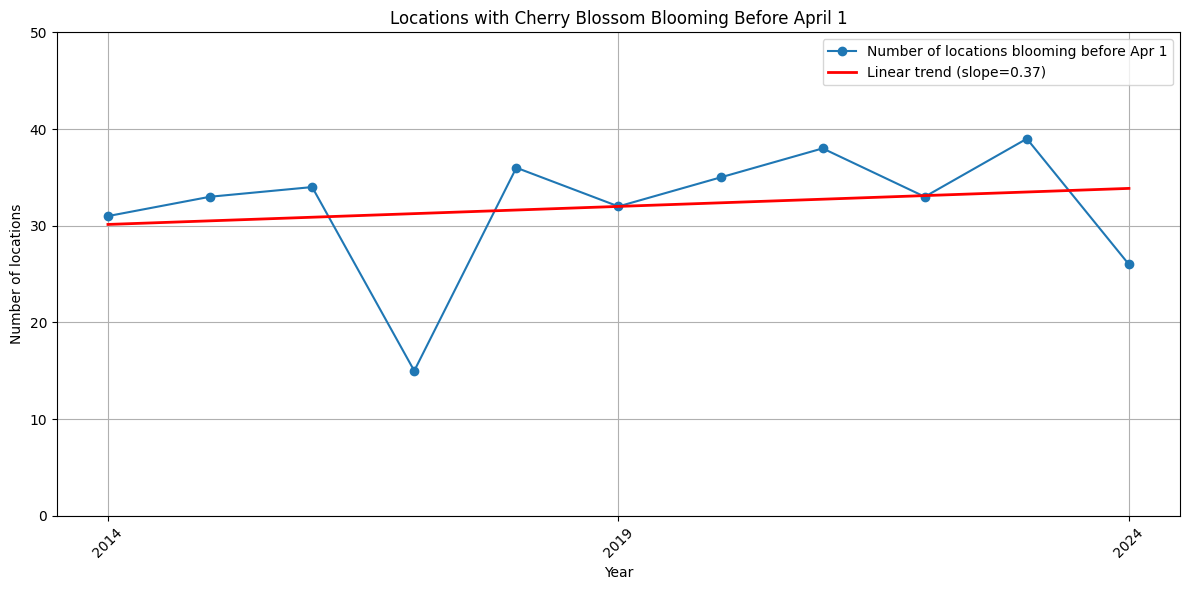

In [8]:
# ------------------------------------------------------------------------------
# 01．  気象庁のオープンデータから全国の観測地点におけるさくらの開花日データを取得
#       データクリーニングと取得
#       CSVファイルへ書込む
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# (01-01) Shift-JIS形式のCSVファイルを読込む
df = pd.read_csv(
    "01sakura.csv",         # CSVファイル名
    header=None,            # すべての行をデータとみなす
    encoding="shift_jis",   # 文字コード形式
    dtype=str,              # データタイプ
    skiprows=1              # 先頭行を削除
)

# --------------------------------------
# (01-02) データクリーニングとデータ整形

# A列～ER列のうち、A列(0)～EO列(144)の偶数列を抽出
df = df.iloc[:, :145]
# 列のいずれかに "0" が含まれる行を削除
df = df[~(df == "0").any(axis=1)]
# DU列(124)～EO列(144)の偶数列を抽出
df_cleaned = pd.concat([df.iloc[:,1], df.iloc[:, 124:145:2]], axis=1).copy()
# df_cleaned= df_cleaned.reset_index(drop=True)
# df_cleaned.columns = range(len(df_cleaned.columns))
# print(df_cleaned.head())

# 整数 → 年月日に変換
for col in range(1, df_cleaned.shape[1]):
    year = int(df_cleaned.iloc[0, col])
    print(year)
    df_cleaned.iloc[1:, col] = df_cleaned.iloc[1:, col].apply(
        lambda x: pd.Timestamp(
            year=year,
            month=int(x)//100,
            day=int(x)%100
        )
    )

# 行方向に年を，列方向に地点を並べる
df_cleaned = df_cleaned.transpose()

# --------------------------------------
# (01-03) Shift-JIS形式のCSVファイルで保存

df_cleaned.to_csv(
    "01sakura_bloom_dates.csv",
    index=False,                # 1列目に通し番号を付加しない
    header=False,               # 1行目に通し番号を付加しない
    encoding="shift_jis",
)

# 報告
print("データクリーニング完了")


# --------------------------------------
# (01-04) 折れ線グラフの描画

# 先頭行から年ラベルを取得
years = df_cleaned.iloc[1:, 0]

# 日数(y座標)のリスト初期化
counts = []

# 各年について4/1より前に開花した地点数をカウント
for row in range(1, df_cleaned.shape[0]):
    # 各地点の開花日をリスト
    dates = pd.to_datetime(df_cleaned.iloc[row, 1:], errors="coerce")
    # 4/1以前の開花日を数える
    count = ((dates.dt.month < 4) |
             ((dates.dt.month == 4) & (dates.dt.day < 1))).sum()
    # 年ごとに集計する
    counts.append(count)

# 年を数値に変換
x = np.array(years.astype(float))
y = np.array(counts)

# 線形回帰
coef = np.polyfit(x, y, 1)      # 傾き・切片
trend = np.poly1d(coef)         # y座標

# 可視化
plt.figure(figsize=(12, 6))

# 元データ
plt.plot(x, y,
         marker="o",
         label="Number of locations blooming before Apr 1")

# 回帰直線（赤）
plt.plot(x, trend(x),
         color="red",
         linewidth=2,
         label=f"Linear trend (slope={coef[0]:.2f})")

plt.ylim(0, 50)
plt.xlabel("Year")
plt.ylabel("Number of locations")
plt.title("Locations with Cherry Blossom Blooming Before April 1")
plt.legend()
plt.grid(True)

# 年が多いので間引いて表示
plt.xticks(x[::5], rotation=45)

plt.tight_layout()
plt.show()





In [ ]:
import pandas as pd

# 観測地点(緯度の降順)
places = [
    '旭川', '帯広', '室蘭', '函館', '秋田', '盛岡', '仙台', '山形', '新潟', '福島',
    '富山', '長野', '金沢', '宇都宮','前橋','水戸', '熊谷', '福井', '銚子', '東京',
    '甲府', '鳥取', '松江', '横浜', '岐阜', '彦根', '名古屋','京都','静岡','津',
    '神戸', '大阪', '岡山', '広島', '高松', '和歌山','徳島', '下関', '松山', '福岡',
    '佐賀','大分', '熊本', '長崎', '鹿児島'
]

def estim_date(df:pd.DataFrame, temp:int, fn: str):

    df.columns = df.iloc[0]  # 先頭行を列名に設定
    df = df.iloc[1:].reset_index(drop=True)  # 先頭行を削除
    df["年月日"] = pd.to_datetime(df["年月日"])

    # 結果を辞書の形で返す
    result = {pt : [] for pt in places}

    # 観測地点ごとに推定日を確定する
    for pt in places:

        # 年月日と観測地点のデータフレームを抽出
        i = 1
        # 各年の推定日を計算
        for y in range(2014, 2025):
            s = 0
            while(s <= temp and df['年月日'].iloc[i].year == y):
                s += float(df[pt].iloc[i])
                i += 1
                if i >= df.shape[0]:
                    break
            # 地点pt のリストに推定日を追加する
            if s > temp:
                result[pt].append(df['年月日'].iloc[i])
                while i < df.shape[0] and df['年月日'].iloc[i].year == y:
                    i += 1
            else:
                result[pt].append(df['年月日'].iloc[i-1])

    # CSVファイルへ書込む
    pd.DataFrame(result).to_csv(fn, encoding='shift-jis')


# 400度(平均気温)/600度(最高気温) 開花推定日の初期化
dfs_ave = pd.DataFrame()
dfs_max = pd.DataFrame()

#   データ整形処理
# 読込み
df = pd.read_csv("02temp_data.csv", header=None, encoding="shift_jis", skiprows=2)
#  削除する行（2,3,4行目 → 0始まりで 1,2,3）
df = df.drop(index=[1, 2, 3]).reset_index(drop=True)

# ----------------------------------------
# 平均気温
# 1列目 + 6n+2列（2,8,14,...列目）
# 0始まりでは 0列 + 1,7,13,...
# ----------------------------------------
mean_cols = [0] + list(range(1, df.shape[1], 6))
mean_df = df.iloc[:, mean_cols]
mean_df.iloc[0,0] = "年月日"
# 400度開花推定日をCSVファイルへ書出す
estim_date(mean_df, 400, '02day400.csv')

# ----------------------------------------
# 最高気温
# 1列目 + 6n+5列（5,11,17,...列目）
# 0始まりでは 0列 + 4,10,16,...
# ----------------------------------------
max_cols = [0] + list(range(4, df.shape[1], 6))
max_df = df.iloc[:, max_cols]
max_df.iloc[0,0] = "年月日"
# 600度開花推定日をCSVファイルへ書出す
estim_date(max_df, 600, '02day600.csv')


/tmp/ipykernel_2229/3427760943.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.iloc[0,0] = "年月日"
/tmp/ipykernel_2229/3427760943.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_df.iloc[0,0] = "年月日"


In [9]:
import pandas as pd

# 読み込み
bloom = pd.read_csv("01sakura_bloom_dates.csv", encoding="shift-jis")
d600 = pd.read_csv("02day600.csv", encoding="shift-jis")
d400 = pd.read_csv("02day400.csv", encoding="shift-jis")

# bloom: 年をインデックス化
bloom = bloom.set_index("地点名")

# day600, day400: 行番号を年に変換
years = bloom.index.astype(int)

d600.index = years
d400.index = years

# 日付型へ変換
bloom = bloom.apply(pd.to_datetime)
d600 = d600.apply(pd.to_datetime)
d400 = d400.apply(pd.to_datetime)

# 列名の空白除去
bloom.columns = bloom.columns.str.strip()
d600.columns = d600.columns.str.strip()
d400.columns = d400.columns.str.strip()

# 列順を bloom に合わせる
d600 = d600[bloom.columns]
d400 = d400[bloom.columns]

# 日数差計算
diff600 = (d600 - bloom).apply(lambda x: x.dt.days)
diff400 = (d400 - bloom).apply(lambda x: x.dt.days)

# 保存
diff600.to_csv("03_600diff.csv", encoding="shift_jis")
diff400.to_csv("03_400diff.csv", encoding="shift_jis")





In [10]:
import pandas as pd

# 読み込み
bloom = pd.read_csv("01sakura_bloom_dates.csv", encoding="shift-jis")
d600 = pd.read_csv("02day600.csv", encoding="shift-jis")
d400 = pd.read_csv("02day400.csv", encoding="shift-jis")

# bloom: 年をインデックス化
bloom = bloom.set_index("地点名")

# day600, day400: 行番号を年に変換
years = bloom.index.astype(int)

d600.index = years
d400.index = years

# 日付型へ変換
bloom = bloom.apply(pd.to_datetime)
d600 = d600.apply(pd.to_datetime)
d400 = d400.apply(pd.to_datetime)

# 列名の空白除去
bloom.columns = bloom.columns.str.strip()
d600.columns = d600.columns.str.strip()
d400.columns = d400.columns.str.strip()

# 列順を bloom に合わせる
d600 = d600[bloom.columns]
d400 = d400[bloom.columns]

# 日数差計算
diff600 = (d600 - bloom).apply(lambda x: x.dt.days)
diff400 = (d400 - bloom).apply(lambda x: x.dt.days)

# 保存
diff600.to_csv("03_600diff.csv", encoding="shift_jis")
diff400.to_csv("03_400diff.csv", encoding="shift_jis")





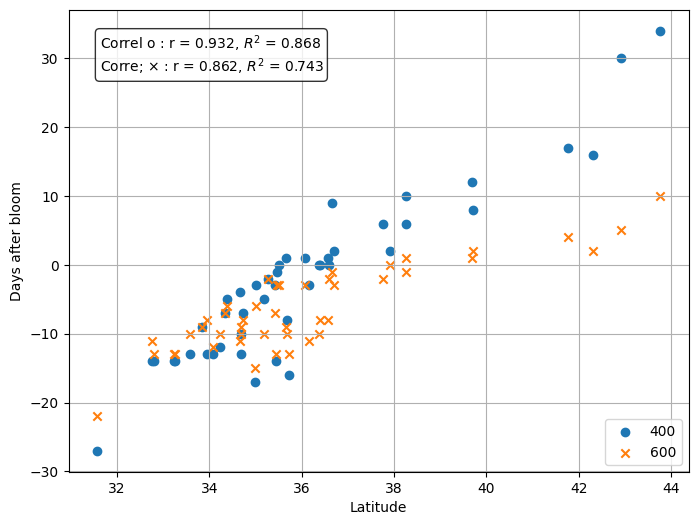

In [11]:
import pandas as pd

# 地点と緯度データ
places = {
    "旭川": 43.77,
    "帯広": 42.92,
    "室蘭": 42.32,
    "函館": 41.77,
    "秋田": 39.72,
    "盛岡": 39.70,
    "山形": 38.25,
    "仙台": 38.26,
    "福島": 37.76,
    "新潟": 37.92,
    "金沢": 36.59,
    "富山": 36.70,
    "長野": 36.65,
    "宇都宮": 36.56,
    "福井": 36.07,
    "前橋": 36.39,
    "熊谷": 36.15,
    "水戸": 36.37,
    "岐阜": 35.42,
    "名古屋": 35.18,
    "甲府": 35.67,
    "銚子": 35.73,
    "津": 34.73,
    "静岡": 34.98,
    "東京": 35.69,
    "横浜": 35.44,
    "松江": 35.47,
    "鳥取": 35.50,
    "京都": 35.01,
    "彦根": 35.27,
    "下関": 33.95,
    "広島": 34.39,
    "岡山": 34.66,
    "神戸": 34.69,
    "大阪": 34.69,
    "和歌山": 34.23,
    "福岡": 33.59,
    "佐賀": 33.25,
    "大分": 33.24,
    "長崎": 32.75,
    "熊本": 32.80,
    "鹿児島": 31.56,
    "松山": 33.84,
    "高松": 34.34,
    "徳島": 34.07
}

#
df400 = pd.read_csv("03_400diff.csv", header=0, encoding='shift-jis')
df600 = pd.read_csv("03_600diff.csv", header=0, encoding='shift-jis')

import matplotlib.pyplot as plt

lats = [lat for pt, lat in places.items()]
d400 = [df400[pt].iloc[10] for pt in places.keys()]
d600 = [df600[pt].iloc[10] for pt in places.keys()]

# 散布図
plt.figure(figsize=(8, 6))

# 400日積算: ○
plt.scatter(
    lats, d400,
    marker='o',
    label='400'
)

# 600日積算: ×
plt.scatter(
    lats, d600,
    marker='x',
    label='600'
)

# 相関係数
import numpy as np
x = np.array(lats)
y1 = np.array(d400)
y2 = np.array(d600)

r1 = np.corrcoef(x, y1)[0, 1]
r2 = np.corrcoef(x, y2)[0, 1]

# 相関係数を表示
plt.text(
    0.05, 0.95,
    f"Correl o : r = {r1:.3f}, $R^2$ = {r1 ** 2:.3f}\nCorre; × : r = {r2:.3f}, $R^2$ = {r2 ** 2:.3f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(
        facecolor="white", # 背景色
        edgecolor="black", # 枠線色
        boxstyle="round", # 枠の形
        alpha=0.8 # 透明度
    )
)

# 軸ラベル
plt.xlabel("Latitude")
plt.ylabel("Days after bloom")
# 凡例
plt.legend()
# グリッド
plt.grid(True)

plt.show()

0                     年月日    旭川   帯広   室蘭   函館   秋田   盛岡   仙台   山形   新潟  ...  \
1212  2024-02-01 00:00:00  -6.2 -5.2 -4.4 -5.1  0.5  0.6  4.4  2.4  3.6  ...   
1213  2024-02-02 00:00:00  -8.7 -6.2 -4.5 -5.0  0.3 -1.0  1.6 -0.1  1.1  ...   
1214  2024-02-03 00:00:00 -11.8 -8.6 -4.3 -4.6 -0.3 -0.5  2.2  0.6  4.3  ...   
1215  2024-02-04 00:00:00  -5.8 -5.9 -1.7 -2.2  3.2  1.7  4.2  2.2  3.4  ...   
1216  2024-02-05 00:00:00 -11.8 -7.8 -2.5 -3.0  1.3 -0.3  1.9  0.6  2.7  ...   

0     和歌山   徳島    下関    松山    福岡    佐賀    大分    熊本    長崎   鹿児島  
1212  9.4  9.6  10.4  10.6  10.9  11.1  11.2  12.0  11.6  14.6  
1213  5.7  5.9   8.3   7.6   9.4   9.8   8.1  10.8  10.3  14.3  
1214  6.5  5.7   5.8   5.3   6.7   7.1   6.2   8.6   8.7  13.0  
1215  6.9  6.4   7.6   7.4   8.8   9.6   7.5  10.9  10.5  14.1  
1216  5.7  5.9   7.4   6.9   8.8   9.8   8.7  11.3  11.1  14.8  

[5 rows x 46 columns]
[34, 30, 16, 17, 8, 12, 10, 9]
[6, 2, 6, 2, 0, 1, 0, 0, -3, 1, -16, -8, 1, 0, -1, -14, -3, -2, -5, -3, -17

/tmp/ipykernel_2229/2876219612.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df_2024.iloc[:, 1:] = mean_df_2024.iloc[:, 1:].astype(float)


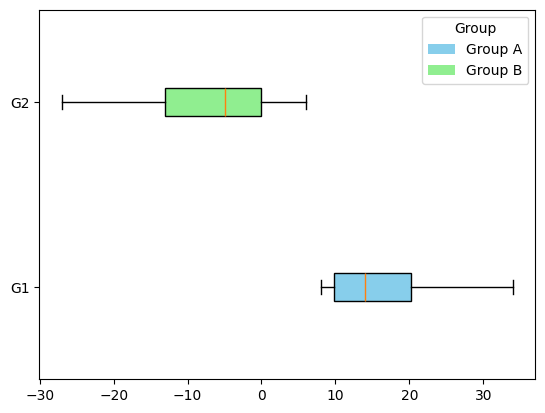

In [12]:
import pandas as pd

# 観測地点(緯度の降順)
places = [
    '旭川', '帯広', '室蘭', '函館', '秋田', '盛岡', '仙台', '山形', '新潟', '福島',
    '富山', '長野', '金沢', '宇都宮','前橋','水戸', '熊谷', '福井', '銚子', '東京',
    '甲府', '鳥取', '松江', '横浜', '岐阜', '彦根', '名古屋','京都','静岡','津',
    '神戸', '大阪', '岡山', '広島', '高松', '和歌山','徳島', '下関', '松山', '福岡',
    '佐賀','大分', '熊本', '長崎', '鹿児島'
]


#   データ整形処理
# 読込み
df = pd.read_csv("02temp_data.csv", header=None, encoding="shift_jis", skiprows=2)
#  削除する行（2,3,4行目 → 0始まりで 1,2,3）
df = df.drop(index=[1, 2, 3]).reset_index(drop=True)

# 先頭行は列名
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

#


# ----------------------------------------
# 平均気温
# 1列目 + 6n+2列（2,8,14,...列目）
# 0始まりでは 0列 + 1,7,13,...
# ----------------------------------------
mean_cols = [0] + list(range(1, df.shape[1], 6))
mean_df = df.iloc[:, mean_cols]

# データを日付型へ変換
mean_df.iloc[:, 0] = pd.to_datetime(mean_df.iloc[:, 0])
mean_df_2024 = mean_df[pd.to_datetime(mean_df.iloc[:, 0]).dt.year == 2024]
mean_df_2024.iloc[:, 1:] = mean_df_2024.iloc[:, 1:].astype(float)
print(mean_df_2024.head())

# 平均気温が氷点下(0度以下)の日があった地点の抽出
G1 = [pt for pt in places if not((mean_df_2024[pt].iloc[1:] > 0).all())]
G2 = [pt for pt in places if (mean_df_2024[pt].iloc[1:] > 0).all()]
# print(G1, G2)

df400 = pd.read_csv("03_400diff.csv", header=0, encoding='shift-jis')
d400_2024_G1 = [int(df400[pt].iloc[10]) for pt in G1]
d400_2024_G2 = [int(df400[pt].iloc[10]) for pt in G2]
print(d400_2024_G1)
print(d400_2024_G2)

# 水平方向の箱ひげ図
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots()

bp = ax.boxplot(
    [d400_2024_G1, d400_2024_G2],
    vert=False,
    patch_artist=True,

)

ax.set_yticklabels(['G1', 'G2'])

colors = ["skyblue", "lightgreen"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

legend_elements = [
    Patch(facecolor="skyblue", label="Group A"),
    Patch(facecolor="lightgreen", label="Group B")
]

ax.legend(handles=legend_elements, title="Group")
plt.show()



In [19]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 81.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=354d8dd0a7d64190523879a389891191fc0fbf2977010f4e3717f347228afe2e
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize_matplotlib


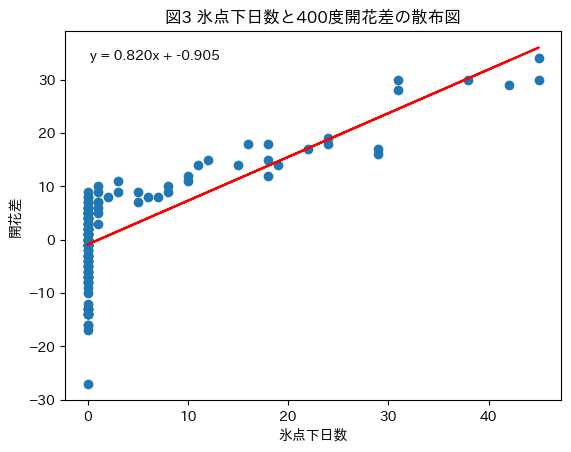

In [21]:
# ------------------------------------------------------------------------------
# 06．氷点下(subzero temperature)日数と400度開花差の散布図と回帰直線
#
#
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

# (06.01) 観測地点(緯度の降順)リスト
places = [
    '旭川', '帯広', '室蘭', '函館', '秋田', '盛岡', '仙台', '山形', '新潟', '福島',
    '富山', '長野', '金沢', '宇都宮','前橋','水戸', '熊谷', '福井', '銚子', '東京',
    '甲府', '鳥取', '松江', '横浜', '岐阜', '彦根', '名古屋','京都','静岡','津',
    '神戸', '大阪', '岡山', '広島', '高松', '和歌山','徳島', '下関', '松山', '福岡',
    '佐賀','大分', '熊本', '長崎', '鹿児島'
]

#  (06.02)．気温データ整形処理
#
#  気温データの読込み
df = pd.read_csv("02temp_data.csv", header=None, encoding="shift_jis", skiprows=2)
#  削除する行（2,3,4行目 → 0始まりで 1,2,3）
df = df.drop(index=[1, 2, 3]).reset_index(drop=True)

#  先頭(0)行は列名として使う．縦方向のインデックスを振り直し
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

#  平均気温の抽出，0列を日付型へ変換, 1列以降はfloat型へ変換
#   1列目 + 6n+2列（2,8,14,...列目）0始まりでは 0列 + 1,7,13,...
mean_cols = [0] + list(range(1, df.shape[1], 6))
mean_df = df.iloc[:, mean_cols].copy()
mean_df.iloc[:, 0] = pd.to_datetime(mean_df.iloc[:, 0])
mean_df.iloc[:, 1:] = mean_df.iloc[:, 1:].apply(pd.to_numeric)
# print(mean_df.dtypes)

#  最新3年分の平均気温を抽出，地点・年度毎に平均気温が氷点下(0度以下)の日数を求める
mean_df_2022 = mean_df[(pd.to_datetime(mean_df.iloc[:, 0]).dt.year == 2022)]
X = [mean_df_2022[mean_df_2022[pt].iloc[:] <= 0].shape[0] for pt in places]
mean_df_2023 = mean_df[(pd.to_datetime(mean_df.iloc[:, 0]).dt.year == 2023)]
X += [mean_df_2023[mean_df_2023[pt].iloc[:] <= 0].shape[0] for pt in places]
mean_df_2024 = mean_df[(pd.to_datetime(mean_df.iloc[:, 0]).dt.year == 2024)]
X += [mean_df_2024[mean_df_2024[pt].iloc[:] <= 0].shape[0] for pt in places]
X = np.array(X)
# print(X)

#
# days_U0 = [mean_df_2022_24[mean_df_2022_24[pt].iloc[:] <= 0].shape[0] for pt in places]
# print(days_U0)

# (06.03) 400度開花差データの整形処理
df400 = pd.read_csv("03_400diff.csv", header=0, encoding='shift-jis')
# 地点毎に最近3年の400度開花差日数を求める
Y = [df400[pt].iloc[8] for pt in places]
Y += [df400[pt].iloc[9] for pt in places]
Y += [df400[pt].iloc[10] for pt in places]
Y = np.array(Y)
# print(Y)

# (06.04) 散布図と回帰直線
# 散布図
plt.scatter(X, Y)

# 回帰直線
a, b = np.polyfit(X, Y, 1)
plt.plot(X, a*X + b, color="red")

# 回帰式を表示
plt.text(
    0.05, 0.95,
    f"y = {a:.3f}x + {b:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

# 軸ラベル
plt.xlabel("氷点下日数")
plt.ylabel("開花差")
# タイトル
plt.title("図3 氷点下日数と400度開花差の散布図")

plt.show()

